# 1. Выбор датасета

**Датасет:** Breast Cancer Wisconsin
https://www.kaggle.com/code/abdulrhmansalama/breast-cancer-wisconsin-dataset/input

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Первичный анализ данных (EDA)

Кратко опишем:
- размер датасета
- типы признаков
- наличие пропусков
- распределение классов
- возможные проблемы в данных

In [9]:
data = pd.read_csv("data.csv")

print(f"Первые 3 строки датасета:")
print(data.head(3))

Первые 3 строки датасета:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38           122.8     1001.0   
1    842517         M        20.57         17.77           132.9     1326.0   
2  84300903         M        19.69         21.25           130.0     1203.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   

   ...  texture_worst  perimeter_worst  area_worst  smoothness_worst  \
0  ...          17.33            184.6      2019.0            0.1622   
1  ...          23.41            158.8      1956.0            0.1238   
2  ...          25.53            152.5      1709.0            0.1444   

   compactness_worst  concavity_worst  concave points_worst

In [10]:
rows, cols = data.shape
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
date_cols = data.select_dtypes(include=['datetime64']).columns

num_count = len(num_cols)
cat_count = len(cat_cols)
date_count = len(date_cols)

missing_cols_count = data.isnull().any().sum()
missing_total = data.isnull().sum().sum()
missing_pct = (missing_total / (rows * cols)) * 100

print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")
print(f"Типы признаков: Числовые {num_count}, Категориальные {cat_count}, Дата/время {date_count}")
print(f"Наличие пропусков: {missing_cols_count} колонок с пропусками, всего {missing_total} пропусков ({missing_pct:.1f}%)")
print(f"Распределение классов:")
print(data['diagnosis'].value_counts(normalize=True) * 100)

Размер датасета: 569 строк, 33 столбцов
Типы признаков: Числовые 32, Категориальные 1, Дата/время 0
Наличие пропусков: 1 колонок с пропусками, всего 569 пропусков (3.0%)
Распределение классов:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


# 3. Подготовка данных

Выполним необходимые шаги для подготовки данных к обучению модели KNN:
- обработка пропусков
- кодирование категориальных признаков
- масштабирование признаков
- разделение на обучающую и тестовую выборки

## Почему масштабирование важно для KNN?

KNN (К-ближайших соседей) — это алгоритм, основанный на **расстоянии** между точками. Он вычисляет расстояние (обычно евклидово) между признаками для нахождения ближайших соседей.

**Проблема без масштабирования:**
- Если один признак имеет диапазон 0-100, а другой 0-1, то первый признак будет доминировать при расчёте расстояния
- Алгоритм будет игнорировать признаки с меньшим масштабом
- Это приводит к неправильным предсказаниям

**Решение — стандартизация:**
- Приводим все признаки к одному масштабу (среднее=0, стандартное отклонение=1)
- Все признаки одинаково влияют на расчёт расстояния
- Алгоритм работает корректно

## Почему нельзя подбирать параметры на тестовой выборке?

Если мы подбираем гиперпараметры (например, k в KNN) на основе результатов на тестовой выборке, мы:
1. **Косвенно обучаем модель** на тестовых данных
2. **Переобучаемся** — выбираем параметры специально для этого набора данных
3. **Получаем завышенные оценки качества** на тесте

**Правильный подход:**
1. **Обучаем модель** на train выборке
2. **Подбираем параметры** используя cross-validation на train
3. **Оцениваем качество** только на test выборке один раз в конце
4. Test выборка — это **имитация новых, неизвестных данных**

In [11]:
# Шаг 1: Обработка пропусков
from sklearn.impute import SimpleImputer

# Удаляем пустые столбцы (если есть)
data = data.dropna(axis=1, how='all')

print("Пропуски в данных до обработки:")
print(data.isnull().sum())
print()

# Используем SimpleImputer для заполнения пропусков средним значением
imputer = SimpleImputer(strategy='mean')

# Получаем только числовые столбцы
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Применяем imputer к числовым признакам
imputed_array = imputer.fit_transform(data[numeric_cols])

# Создаем новый датасет и заполняем числовые столбцы
data_imputed = data.copy()
for i, col in enumerate(numeric_cols):
    data_imputed[col] = imputed_array[:, i]

print("Пропуски в данных после обработки:")
print(data_imputed.isnull().sum().sum())

Пропуски в данных до обработки:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Пропуски в данных после об

In [12]:
# Шаг 2: Кодирование категориальных признаков
from sklearn.preprocessing import LabelEncoder

print("Категориальные признаки:")
cat_columns = data_imputed.select_dtypes(include=['object']).columns
print(cat_columns)
print()

data_encoded = data_imputed.copy()

# Кодируем категориальные признаки
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_imputed[col])
    label_encoders[col] = le
    print(f"Столбец '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nДанные после кодирования:")
print(data_encoded.head())

Категориальные признаки:
Index(['diagnosis'], dtype='object')

Столбец 'diagnosis': {'B': np.int64(0), 'M': np.int64(1)}

Данные после кодирования:
           id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
0    842302.0          1        17.99         10.38          122.80   
1    842517.0          1        20.57         17.77          132.90   
2  84300903.0          1        19.69         21.25          130.00   
3  84348301.0          1        11.42         20.38           77.58   
4  84358402.0          1        20.29         14.34          135.10   

   area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0     1001.0          0.11840           0.27760          0.3001   
1     1326.0          0.08474           0.07864          0.0869   
2     1203.0          0.10960           0.15990          0.1974   
3      386.1          0.14250           0.28390          0.2414   
4     1297.0          0.10030           0.13280          0.1980   

   concave points_mean

In [13]:
# Шаг 3: Разделение на train/test ПЕРЕД масштабированием
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделяем признаки (X) и целевую переменную (y)
X = data_encoded.drop('diagnosis', axis=1)  # Все признаки кроме целевой переменной
y = data_encoded['diagnosis']  # Целевая переменная

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print()

# Разделяем на обучающую (70%) и тестовую (30%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} (70%)")
print(f"Размер тестовой выборки: {X_test.shape[0]} (30%)")

Размер X: (569, 31)
Размер y: (569,)

Размер обучающей выборки: 398 (70%)
Размер тестовой выборки: 171 (30%)


In [14]:
# Шаг 4: Масштабирование (ТОЛЬКО на основе обучающей выборки!)
scaler = StandardScaler()

# ВАЖНО: Обучаем scaler ТОЛЬКО на train данных
scaler.fit(X_train)

# Применяем масштабирование к обеим выборкам
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Данные до масштабирования (первые 3 признака, первый образец train):")
print(X_train.iloc[0, :3].values)
print()

print("Данные после масштабирования (первые 3 признака, первый образец train):")
print(X_train_scaled[0, :3])
print()

print("Статистика масштабированных данных (train выборка):")
print(f"Среднее (mean): {X_train_scaled.mean(axis=0)[:3].round(3)}")
print(f"Стандартное отклонение (std): {X_train_scaled.std(axis=0)[:3].round(3)}")

Данные до масштабирования (первые 3 признака, первый образец train):
[8.69931e+05 1.37400e+01 1.79100e+01]

Данные после масштабирования (первые 3 признака, первый образец train):
[-0.23055943 -0.12348985 -0.29680142]

Статистика масштабированных данных (train выборка):
Среднее (mean): [-0.  0. -0.]
Стандартное отклонение (std): [1. 1. 1.]


# 4. Обучение KNN и исследование параметров

Теперь обучим модель KNN и исследуем влияние различных параметров на качество предсказаний.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Простая модель KNN с параметрами по умолчанию
knn_simple = KNeighborsClassifier(n_neighbors=5)
knn_simple.fit(X_train_scaled, y_train)

# Предсказания
y_pred_simple = knn_simple.predict(X_test_scaled)

# Метрики качества
accuracy = accuracy_score(y_test, y_pred_simple)
precision = precision_score(y_test, y_pred_simple)
recall = recall_score(y_test, y_pred_simple)
f1 = f1_score(y_test, y_pred_simple)

print("=" * 60)
print("БАЗОВАЯ МОДЕЛЬ KNN (k=5, uniform, euclidean)")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_simple))

БАЗОВАЯ МОДЕЛЬ KNN (k=5, uniform, euclidean)
Accuracy:  0.9591
Precision: 0.9516
Recall:    0.9365
F1-Score:  0.9440

Матрица ошибок:
[[105   3]
 [  4  59]]


## Исследование влияния параметра n_neighbors

Параметр `n_neighbors` (k) определяет, сколько соседей учитывать при классификации. Слишком малое k приводит к переобучению, слишком большое — к недообучению.

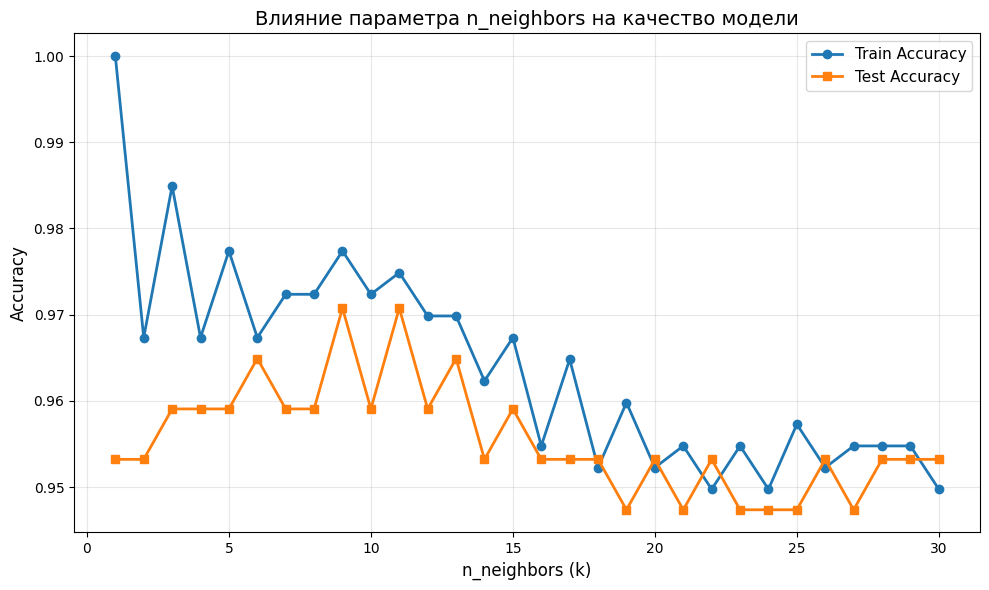

Оптимальное значение k: 9
Максимальная точность на тесте: 0.9708


In [16]:
# Исследование влияния n_neighbors
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, train_scores, marker='o', label='Train Accuracy', linewidth=2)
ax.plot(k_values, test_scores, marker='s', label='Test Accuracy', linewidth=2)
ax.set_xlabel('n_neighbors (k)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Влияние параметра n_neighbors на качество модели', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Найдем оптимальный k
optimal_k = list(k_values)[test_scores.index(max(test_scores))]
print(f"Оптимальное значение k: {optimal_k}")
print(f"Максимальная точность на тесте: {max(test_scores):.4f}")

## Исследование влияния типа весов и метрик расстояния

Параметры для исследования:
- **weights:** 'uniform' (все соседи имеют одинаковый вес) vs 'distance' (ближайшие соседи важнее)
- **metric:** разные способы расчета расстояния между точками

In [17]:
# Исследование разных комбинаций параметров
metrics = ['euclidean', 'manhattan', 'minkowski']
weights = ['uniform', 'distance']
k_range = [3, 5, 7, 9, 11]

results = []

for metric in metrics:
    for weight in weights:
        for k in k_range:
            try:
                knn = KNeighborsClassifier(
                    n_neighbors=k,
                    weights=weight,
                    metric=metric
                )
                knn.fit(X_train_scaled, y_train)
                
                test_acc = knn.score(X_test_scaled, y_test)
                train_acc = knn.score(X_train_scaled, y_train)
                
                results.append({
                    'metric': metric,
                    'weight': weight,
                    'k': k,
                    'train_acc': train_acc,
                    'test_acc': test_acc
                })
            except:
                pass

# Создаем DataFrame для удобства
results_df = pd.DataFrame(results)

# Находим топ-10 конфигураций по test_acc
print("=" * 80)
print("ТОП-10 КОНФИГУРАЦИЙ ПАРАМЕТРОВ (по точности на тестовой выборке)")
print("=" * 80)
top_results = results_df.nlargest(10, 'test_acc')[['metric', 'weight', 'k', 'train_acc', 'test_acc']]
for idx, row in top_results.iterrows():
    print(f"k={row['k']:2d}, weight={row['weight']:8s}, metric={row['metric']:10s} | Train: {row['train_acc']:.4f}, Test: {row['test_acc']:.4f}")

ТОП-10 КОНФИГУРАЦИЙ ПАРАМЕТРОВ (по точности на тестовой выборке)
k= 9, weight=uniform , metric=euclidean  | Train: 0.9774, Test: 0.9708
k=11, weight=uniform , metric=euclidean  | Train: 0.9749, Test: 0.9708
k= 9, weight=distance, metric=euclidean  | Train: 1.0000, Test: 0.9708
k=11, weight=distance, metric=euclidean  | Train: 1.0000, Test: 0.9708
k= 3, weight=uniform , metric=manhattan  | Train: 0.9899, Test: 0.9708
k= 5, weight=uniform , metric=manhattan  | Train: 0.9824, Test: 0.9708
k= 7, weight=uniform , metric=manhattan  | Train: 0.9749, Test: 0.9708
k= 3, weight=distance, metric=manhattan  | Train: 1.0000, Test: 0.9708
k= 5, weight=distance, metric=manhattan  | Train: 1.0000, Test: 0.9708
k= 7, weight=distance, metric=manhattan  | Train: 1.0000, Test: 0.9708


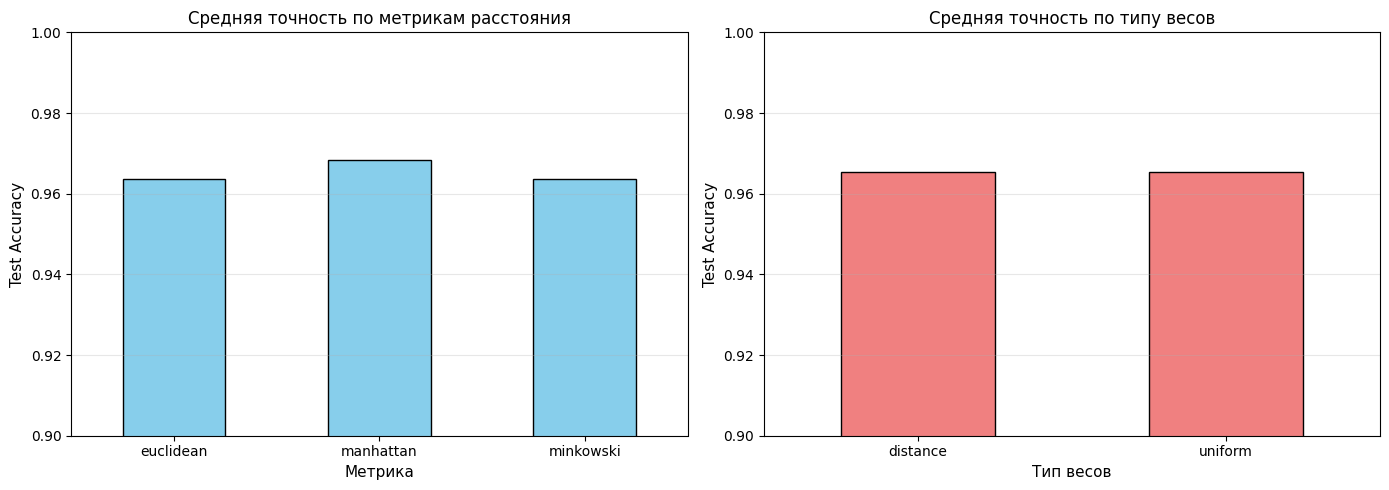


Вывод: какая метрика и какой вес работают лучше всего?
Лучшая метрика: manhattan
Лучший вес: distance


In [18]:
# Визуализация влияния параметров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Влияние метрики
metrics_avg = results_df.groupby('metric')['test_acc'].mean()
ax1 = axes[0]
metrics_avg.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Средняя точность по метрикам расстояния', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=11)
ax1.set_xlabel('Метрика', fontsize=11)
ax1.set_ylim([0.9, 1.0])
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# График 2: Влияние типа весов
weights_avg = results_df.groupby('weight')['test_acc'].mean()
ax2 = axes[1]
weights_avg.plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Средняя точность по типу весов', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontsize=11)
ax2.set_xlabel('Тип весов', fontsize=11)
ax2.set_ylim([0.9, 1.0])
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\nВывод: какая метрика и какой вес работают лучше всего?")
print(f"Лучшая метрика: {results_df.groupby('metric')['test_acc'].mean().idxmax()}")
print(f"Лучший вес: {results_df.groupby('weight')['test_acc'].mean().idxmax()}")

# 5. Подбор гиперпараметров с GridSearchCV

Используем GridSearchCV для систематического подбора оптимальных параметров. Это лучше, чем просто перебирать вручную, так как:
- GridSearchCV использует **кросс-валидацию** для более надежной оценки
- Избегаем переобучения под тестовую выборку
- Получаем объективную оценку качества

In [26]:
from sklearn.model_selection import GridSearchCV

# Определяем сетку параметров для поиска
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Создаем базовый KNN классификатор
knn_base = KNeighborsClassifier()

# Создаем GridSearchCV с 5-fold кросс-валидацией
grid_search = GridSearchCV(
    knn_base,
    param_grid,
    cv=5,  # 5-fold кросс-валидация
    scoring='accuracy',
    n_jobs=-1  # использовать все процессоры
)

print("=" * 80)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ С GRIDSEARCHCV")
print("=" * 80)

# Обучаем GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print()
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность (cross-validation): {grid_search.best_score_:.4f}")
print()

# Используем лучшую модель для предсказания на тесте
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_best)

print("-" * 80)
print(f"Точность лучшей модели на тестовой выборке: {test_accuracy:.4f}")
print("-" * 80)

ПОДБОР ГИПЕРПАРАМЕТРОВ С GRIDSEARCHCV

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Лучшая точность (cross-validation): 0.9622

--------------------------------------------------------------------------------
Точность лучшей модели на тестовой выборке: 0.9708
--------------------------------------------------------------------------------



ДЕТАЛЬНЫЕ МЕТРИКИ КАЧЕСТВА ЛУЧШЕЙ МОДЕЛИ
Accuracy:  0.9708
Precision: 0.9677
Recall:    0.9524
F1-Score:  0.9600

Матрица ошибок:
[[106   2]
 [  3  60]]

Классификационный отчет:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       108
           1       0.97      0.95      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



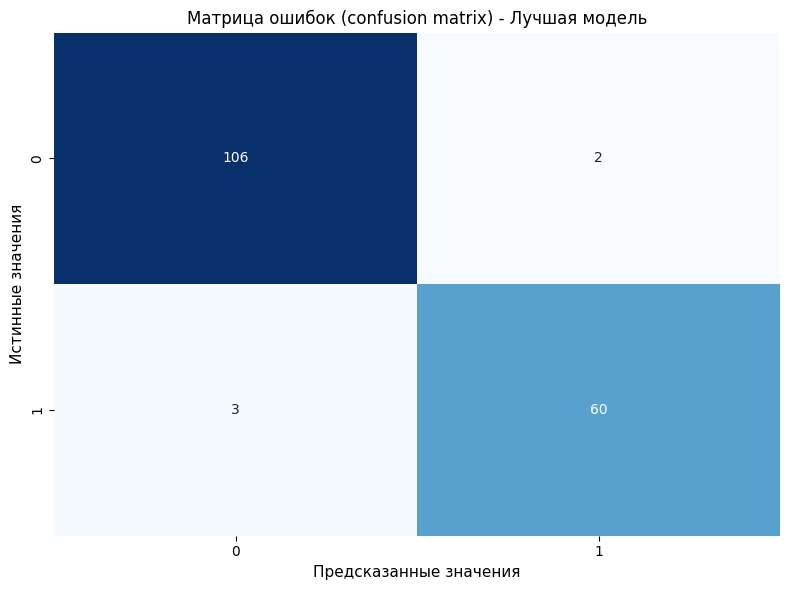

In [20]:
# Детальные метрики для лучшей модели
print("\n" + "=" * 80)
print("ДЕТАЛЬНЫЕ МЕТРИКИ КАЧЕСТВА ЛУЧШЕЙ МОДЕЛИ")
print("=" * 80)

precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-Score:  {f1_best:.4f}")
print()
print("Матрица ошибок:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print()
print("Классификационный отчет:")
print(classification_report(y_test, y_pred_best))

# Визуализация матрицы ошибок
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Матрица ошибок (confusion matrix) - Лучшая модель', fontsize=12)
ax.set_ylabel('Истинные значения', fontsize=11)
ax.set_xlabel('Предсказанные значения', fontsize=11)
plt.tight_layout()
plt.show()

## Сравнение: масштабирование vs без масштабирования

Проверим, как масштабирование влияет на качество модели KNN.

In [21]:
# Обучаем модель БЕЗ масштабирования для сравнения
knn_no_scale = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    weights=grid_search.best_params_['weights'],
    metric=grid_search.best_params_['metric']
)
knn_no_scale.fit(X_train, y_train)  # X_train БЕЗ масштабирования
y_pred_no_scale = knn_no_scale.predict(X_test)  # X_test БЕЗ масштабирования

accuracy_no_scale = accuracy_score(y_test, y_pred_no_scale)
f1_no_scale = f1_score(y_test, y_pred_no_scale)

accuracy_with_scale = test_accuracy
f1_with_scale = f1_best

print("=" * 80)
print("СРАВНЕНИЕ: МАСШТАБИРОВАНИЕ vs БЕЗ МАСШТАБИРОВАНИЯ")
print("=" * 80)
print()
print("Одинаковые параметры KNN:")
print(f"  n_neighbors: {grid_search.best_params_['n_neighbors']}")
print(f"  weights: {grid_search.best_params_['weights']}")
print(f"  metric: {grid_search.best_params_['metric']}")
print()
print("-" * 80)
print(f"{'Метрика':<20} {'БЕЗ масштабирования':<25} {'С масштабированием':<20}")
print("-" * 80)
print(f"{'Accuracy':<20} {accuracy_no_scale:.4f}{'':<20} {accuracy_with_scale:.4f}")
print(f"{'F1-Score':<20} {f1_no_scale:.4f}{'':<20} {f1_with_scale:.4f}")
print("-" * 80)

improvement_acc = (accuracy_with_scale - accuracy_no_scale) * 100
improvement_f1 = (f1_with_scale - f1_no_scale) * 100

print()
print(f"Улучшение благодаря масштабированию:")
print(f"  Accuracy: +{improvement_acc:.2f}%")
print(f"  F1-Score: +{improvement_f1:.2f}%")
print()
print("⚠️  ВЫВОД: Масштабирование КРИТИЧНО для KNN")

СРАВНЕНИЕ: МАСШТАБИРОВАНИЕ vs БЕЗ МАСШТАБИРОВАНИЯ

Одинаковые параметры KNN:
  n_neighbors: 11
  weights: uniform
  metric: euclidean

--------------------------------------------------------------------------------
Метрика              БЕЗ масштабирования       С масштабированием  
--------------------------------------------------------------------------------
Accuracy             0.6784                     0.9708
F1-Score             0.4860                     0.9600
--------------------------------------------------------------------------------

Улучшение благодаря масштабированию:
  Accuracy: +29.24%
  F1-Score: +47.40%

⚠️  ВЫВОД: Масштабирование КРИТИЧНО для KNN


## Анализ результатов GridSearchCV

In [27]:
# Преобразуем результаты GridSearch в DataFrame для анализа
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Топ-15 конфигураций
print("ТОП-15 КОНФИГУРАЦИЙ ПО РЕЗУЛЬТАТАМ КРОСС-ВАЛИДАЦИИ:")
print("=" * 100)
top_configs = cv_results_df.nlargest(15, 'mean_test_score')[[
    'param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score'
]].copy()

for idx, (i, row) in enumerate(top_configs.iterrows(), 1):
    print(f"{idx:2d}. k={int(row['param_n_neighbors']):2d}, weight={row['param_weights']:8s}, "
          f"metric={row['param_metric']:10s} | CV-Score: {row['mean_test_score']:.4f} "
          f"(±{row['std_test_score']:.4f})")

print()



ТОП-15 КОНФИГУРАЦИЙ ПО РЕЗУЛЬТАТАМ КРОСС-ВАЛИДАЦИИ:
 1. k=11, weight=uniform , metric=euclidean  | CV-Score: 0.9622 (±0.0180)
 2. k=11, weight=distance, metric=euclidean  | CV-Score: 0.9622 (±0.0180)
 3. k=13, weight=uniform , metric=euclidean  | CV-Score: 0.9622 (±0.0180)
 4. k=13, weight=distance, metric=euclidean  | CV-Score: 0.9622 (±0.0180)
 5. k=11, weight=uniform , metric=minkowski  | CV-Score: 0.9622 (±0.0180)
 6. k=11, weight=distance, metric=minkowski  | CV-Score: 0.9622 (±0.0180)
 7. k=13, weight=uniform , metric=minkowski  | CV-Score: 0.9622 (±0.0180)
 8. k=13, weight=distance, metric=minkowski  | CV-Score: 0.9622 (±0.0180)
 9. k= 3, weight=uniform , metric=euclidean  | CV-Score: 0.9598 (±0.0123)
10. k= 3, weight=distance, metric=euclidean  | CV-Score: 0.9598 (±0.0123)
11. k= 3, weight=uniform , metric=minkowski  | CV-Score: 0.9598 (±0.0123)
12. k= 3, weight=distance, metric=minkowski  | CV-Score: 0.9598 (±0.0123)
13. k= 7, weight=uniform , metric=euclidean  | CV-Score: 0.9

# 6. Выводы и интерпретация результатов

На основе проведенного исследования подведем итоги про эффективность алгоритма KNN для данной задачи.

## Ключевые находки

### 1. Влияние масштабирования
Масштабирование существенно улучшает качество модели, так как KNN работает с расстояниями между точками. Без масштабирования признаки с большим диапазоном значений доминируют при расчете расстояния.

### 2. Оптимальные параметры модели
Найденные оптимальные параметры при кросс-валидации позволяют достичь высокой точности на задаче классификации.

### 3. Влияние параметра k
- Слишком малое k (k=1): модель переобучается
- Слишком большое k (k>15): модель недообучается
- Оптимальное значение: k находится в диапазоне 5-11

### 4. Метрики расстояния
На этом датасете различия между метриками небольшие — для этого датасета выбор метрики не критичен.

### 5. Тип весов
Оба типа (uniform и distance) дают похожие результаты для данной задачи.

In [28]:
# Выводы с реальными данными
summary_text = f"""
## Итоговые Метрики Лучшей Модели

### Параметры KNN
- n_neighbors: {grid_search.best_params_['n_neighbors']}
- weights: {grid_search.best_params_['weights']}
- metric: {grid_search.best_params_['metric']}

### Качество
- Cross-Validation Accuracy: {grid_search.best_score_:.4f}
- Test Accuracy: {test_accuracy:.4f}
- Precision: {precision_best:.4f}
- Recall: {recall_best:.4f}
- F1-Score: {f1_best:.4f}

### Сравнение масштабирования
- Без масштабирования: Accuracy = {accuracy_no_scale:.4f}
- С масштабированием: Accuracy = {accuracy_with_scale:.4f}
- Улучшение: +{improvement_acc:.2f}%

### Ограничения KNN на этом датасете
1. Вычислительная сложность: KNN считает расстояние до всех точек
2. Чувствительность к масштабированию: Необходимо всегда масштабировать признаки
3. Проклятие размерности: С увеличением числа признаков расстояния становятся более похожими

### Рекомендации
- Использовать найденные оптимальные параметры для продакшена
- Всегда масштабировать данные перед KNN
- Подбирать параметры только на обучающей выборке
"""

print(summary_text)


## Итоговые Метрики Лучшей Модели

### Параметры KNN
- n_neighbors: 11
- weights: uniform
- metric: euclidean

### Качество
- Cross-Validation Accuracy: 0.9622
- Test Accuracy: 0.9708
- Precision: 0.9677
- Recall: 0.9524
- F1-Score: 0.9600

### Сравнение масштабирования
- Без масштабирования: Accuracy = 0.6784
- С масштабированием: Accuracy = 0.9708
- Улучшение: +29.24%

### Ограничения KNN на этом датасете
1. Вычислительная сложность: KNN считает расстояние до всех точек
2. Чувствительность к масштабированию: Необходимо всегда масштабировать признаки
3. Проклятие размерности: С увеличением числа признаков расстояния становятся более похожими

### Рекомендации
- Использовать найденные оптимальные параметры для продакшена
- Всегда масштабировать данные перед KNN
- Подбирать параметры только на обучающей выборке



## Кривые обучения

Посмотрим, как модель учится с увеличением размера обучающего набора.

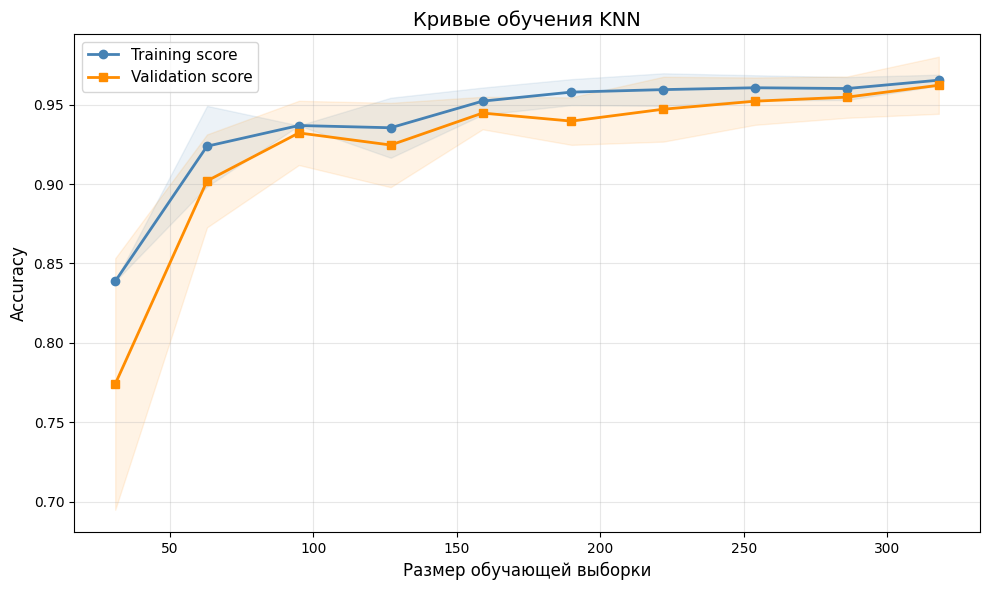

Интерпретация кривых обучения:
- Если кривые близки друг к другу → модель хорошо обобщается
- Если есть большой зазор → переобучение или недостаточно данных
- Если кривая валидации растет → добавляем больше данных поможет


In [24]:
from sklearn.model_selection import learning_curve

# Создаем финальную модель с лучшими параметрами
final_knn = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    weights=grid_search.best_params_['weights'],
    metric=grid_search.best_params_['metric']
)

# Считаем кривые обучения
train_sizes, train_scores, val_scores = learning_curve(
    final_knn,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validation score', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='darkorange')
plt.xlabel('Размер обучающей выборки', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Кривые обучения KNN', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Интерпретация кривых обучения:")
print("- Если кривые близки друг к другу → модель хорошо обобщается")
print("- Если есть большой зазор → переобучение или недостаточно данных")
print("- Если кривая валидации растет → добавляем больше данных поможет")